In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv
/kaggle/input/datasets/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Wine Quality dataset
df = pd.read_csv(
    "/kaggle/input/datasets/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [28]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate Rows:
240


Wine Quality Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


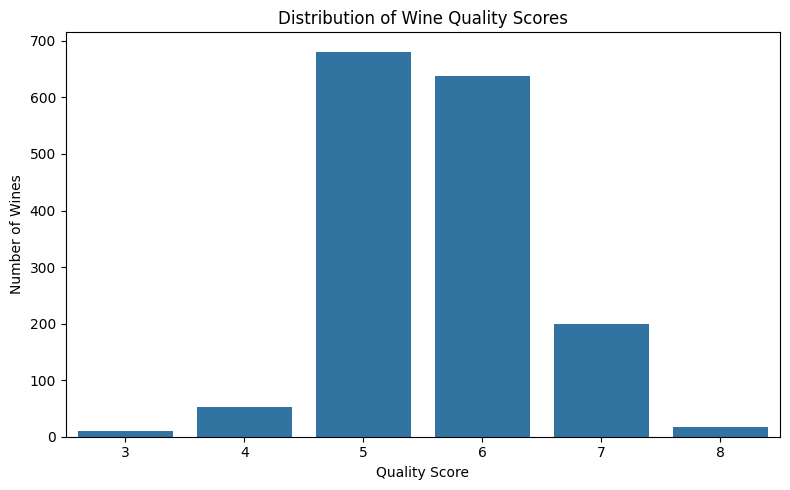

In [29]:
print("Wine Quality Distribution:")
print(df["quality"].value_counts().sort_index())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality"
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()

## 2. Class Distribution

The wine quality scores are not evenly distributed across all quality levels. Some quality classes contain considerably more observations than others.

This class imbalance is important because a classification model may perform better on the majority classes while having difficulty predicting minority classes. Therefore, class distribution should be considered when evaluating the classification models.

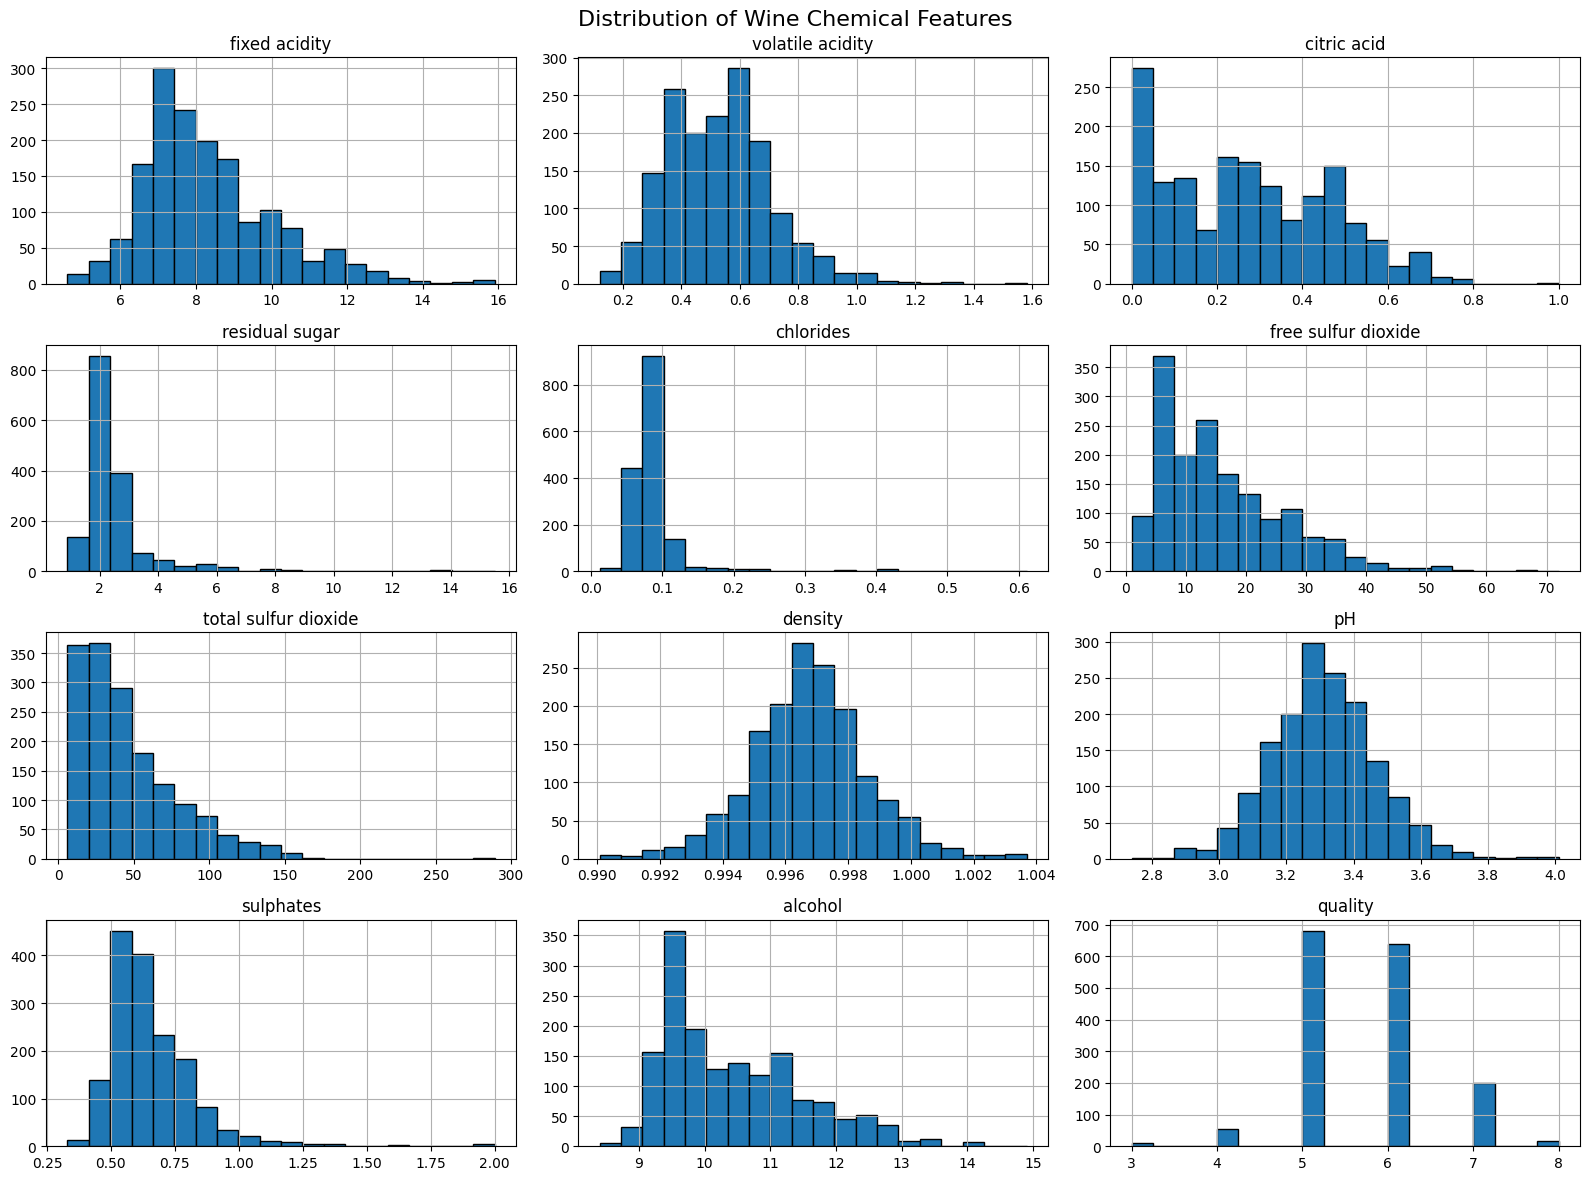

In [30]:
# Distribution of all numerical features

df.hist(
    figsize=(16, 12),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Wine Chemical Features", fontsize=16)
plt.tight_layout()
plt.show()

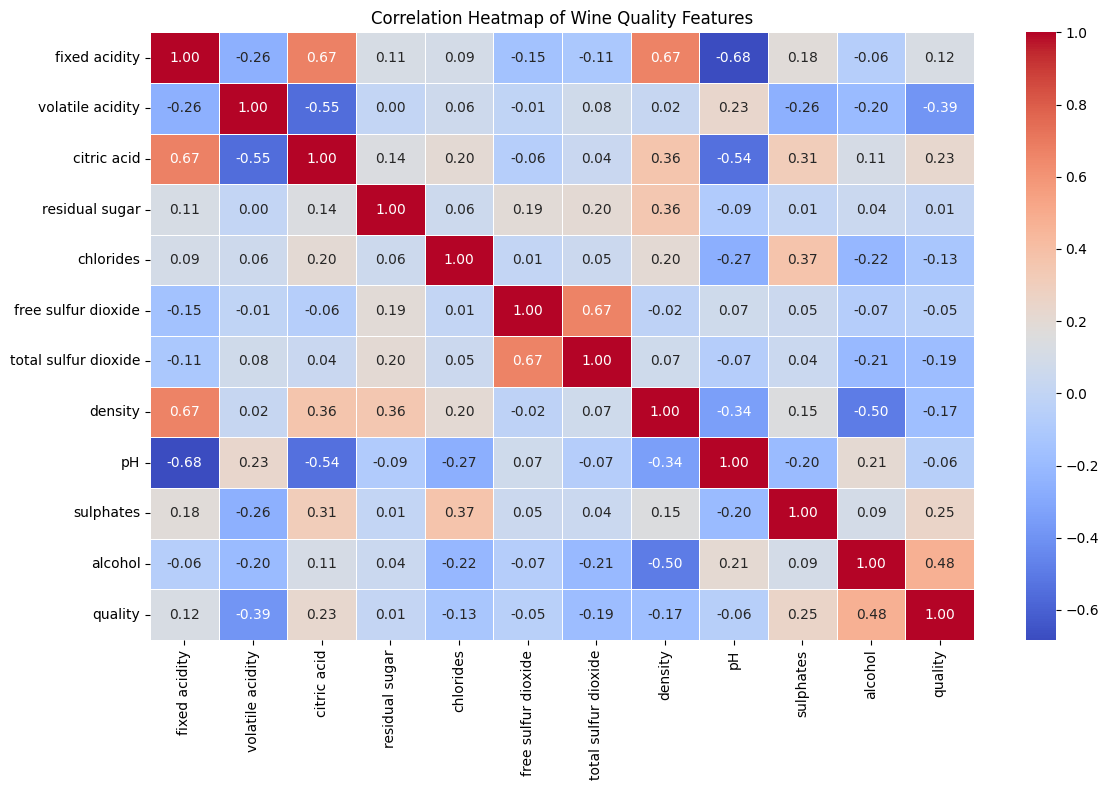

In [31]:
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Wine Quality Features")
plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis

The feature distributions show that the chemical properties of the wines have different ranges and distributions. Some variables such as residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, and sulphates are noticeably skewed.

The correlation heatmap shows the relationships between the physicochemical features and wine quality. Alcohol generally shows a positive relationship with quality, while volatile acidity tends to have a negative relationship.

The features are not perfectly correlated with quality individually, suggesting that combining multiple chemical properties may be useful for classification.

## 4. Class Imbalance

The quality classes are strongly imbalanced:

- Quality 3: 10 wines
- Quality 4: 53 wines
- Quality 5: 681 wines
- Quality 6: 638 wines
- Quality 7: 199 wines
- Quality 8: 18 wines

Quality 5 and 6 account for most observations, while quality 3 and 8 contain very few samples.

This imbalance can affect model performance because a classifier may become biased toward the majority classes. Accuracy alone may therefore not provide a complete picture of model performance. Precision, recall, and F1-score will also be considered when evaluating the classifiers.

In [32]:
# Convert wine quality scores into 3 classes

def classify_quality(quality):
    if quality <= 4:
        return "Low"
    elif quality <= 6:
        return "Medium"
    else:
        return "High"

df["quality_class"] = df["quality"].apply(classify_quality)

print("New Quality Class Distribution:")
print(df["quality_class"].value_counts())

display(df[["quality", "quality_class"]].head(10))

New Quality Class Distribution:
quality_class
Medium    1319
High       217
Low         63
Name: count, dtype: int64


,quality,quality_class
0,5,Medium
1,5,Medium
2,5,Medium
3,6,Medium
4,5,Medium
5,5,Medium
6,5,Medium
7,7,High
8,7,High
9,5,Medium


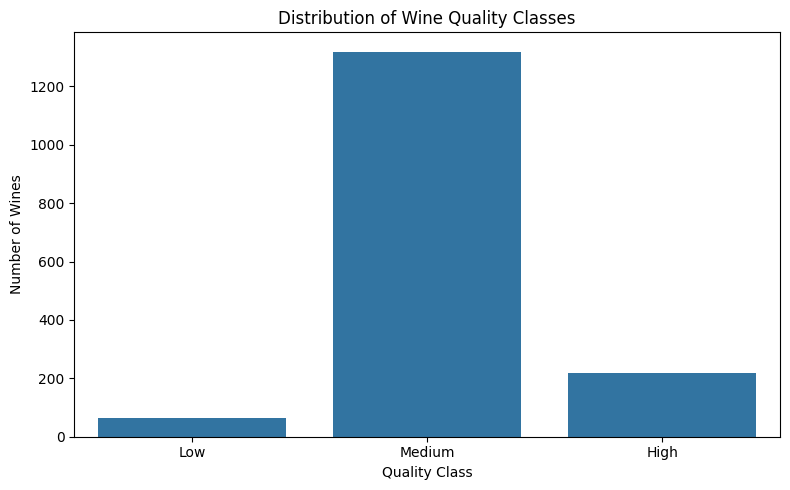

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality_class",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Wine Quality Classes")
plt.xlabel("Quality Class")
plt.ylabel("Number of Wines")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

The original wine quality scores range from 3 to 8. To simplify the classification problem, the scores were grouped into three categories:

- **Low:** Quality scores 3–4
- **Medium:** Quality scores 5–6
- **High:** Quality scores 7–8

This transformation reduces the number of classes and makes the classification problem easier to interpret.

The resulting classes remain imbalanced, with the Medium class containing the majority of observations. Stratified train-test splitting will therefore be used to preserve the class proportions in both datasets.

In [34]:
# Separate features and target

X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:")
print(y.value_counts())

Feature shape: (1599, 11)
Target shape: (1599,)

Target classes:
quality_class
Medium    1319
High       217
Low         63
Name: count, dtype: int64


## 6. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

Stratified sampling is used to preserve the proportion of Low, Medium, and High wine-quality classes in both the training and testing datasets. This is particularly important because the target classes are imbalanced.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set shape: (1279, 11)
Testing set shape: (320, 11)

Training class distribution:
quality_class
Medium    1055
High       174
Low         50
Name: count, dtype: int64

Testing class distribution:
quality_class
Medium    264
High       43
Low        13
Name: count, dtype: int64


## 7. Feature Scaling

The chemical features have different numerical ranges. StandardScaler is therefore used to standardize the features before training the classification models.

The scaler is fitted only on the training data and then applied to both the training and testing data to avoid data leakage.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training shape: (1279, 11)
Scaled testing shape: (320, 11)


## 8. Random Forest Classifier

Random Forest is an ensemble classification algorithm that combines multiple decision trees to make predictions.

It is suitable for this task because it can capture nonlinear relationships between wine chemical properties and quality classes.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [38]:
class_weight="balanced"

## 9. Stochastic Gradient Descent Classifier

The Stochastic Gradient Descent (SGD) classifier is a linear classification algorithm that is efficient for machine learning problems.

The model is trained using the standardized features.

In [39]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3,
    class_weight="balanced"
)

sgd_model.fit(X_train_scaled, y_train)

sgd_pred = sgd_model.predict(X_test_scaled)

print("SGD Classifier training completed.")

SGD Classifier training completed.


## 10. Support Vector Classifier

Support Vector Classifier (SVC) is a supervised classification algorithm that finds decision boundaries between classes.

Because SVC is sensitive to feature scales, the standardized features are used for training.

In [40]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_pred = svc_model.predict(X_test_scaled)

print("SVC training completed.")

SVC training completed.


from sklearn.svm import SVC

svc_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_pred = svc_model.predict(X_test_scaled)

print("SVC training completed.")

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Random Forest": rf_pred,
    "SGD Classifier": sgd_pred,
    "SVC": svc_pred
}

results = []

for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, predictions, average="weighted", zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.868750,0.827545,0.868750,0.845766
1,SGD Classifier,0.778125,0.792915,0.778125,0.784826
2,SVC,0.709375,0.815044,0.709375,0.744791


## 12. Detailed Classification Reports

Overall metrics can hide poor performance on minority classes. Therefore, classification reports are generated for each model to examine precision, recall, and F1-score for Low, Medium, and High wine-quality classes individually.

In [42]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("=" * 50)
print(classification_report(y_test, rf_pred, zero_division=0))

print("\nSGD Classifier Classification Report")
print("=" * 50)
print(classification_report(y_test, sgd_pred, zero_division=0))

print("\nSVC Classification Report")
print("=" * 50)
print(classification_report(y_test, svc_pred, zero_division=0))

Random Forest Classification Report
              precision    recall  f1-score   support

        High       0.71      0.56      0.62        43
         Low       0.00      0.00      0.00        13
      Medium       0.89      0.96      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.51      0.52       320
weighted avg       0.83      0.87      0.85       320


SGD Classifier Classification Report
              precision    recall  f1-score   support

        High       0.49      0.42      0.45        43
         Low       0.09      0.15      0.11        13
      Medium       0.88      0.87      0.87       264

    accuracy                           0.78       320
   macro avg       0.48      0.48      0.48       320
weighted avg       0.79      0.78      0.78       320


SVC Classification Report
              precision    recall  f1-score   support

        High       0.40      0.74      0.52        43
         Low       0.10     

## 13. Confusion Matrix

Confusion matrices are used to examine the classification errors made by each model.

They show how many wines from each actual quality class were correctly or incorrectly classified as Low, Medium, or High.

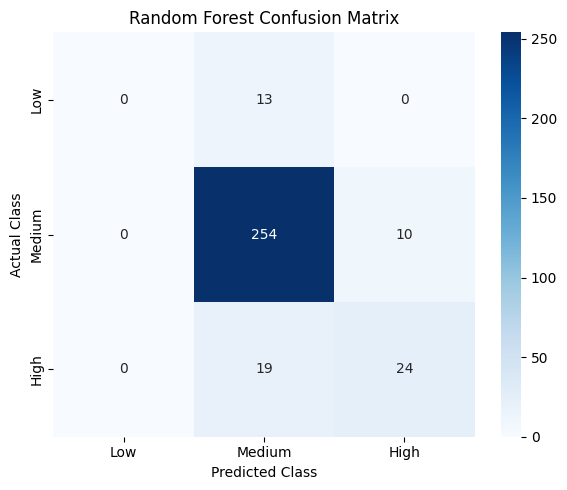

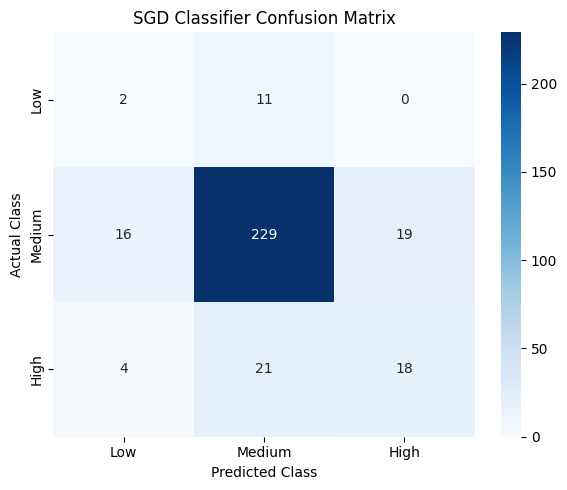

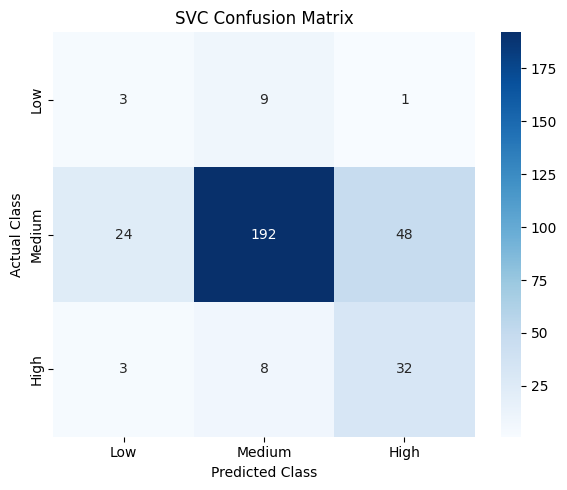

In [43]:
from sklearn.metrics import confusion_matrix

model_predictions = {
    "Random Forest": rf_pred,
    "SGD Classifier": sgd_pred,
    "SVC": svc_pred
}

class_labels = ["Low", "Medium", "High"]

for model_name, predictions in model_predictions.items():
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=class_labels
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

## 14. Random Forest Feature Importance

Random Forest provides feature-importance scores that indicate how useful each chemical feature was for predicting wine quality.

Higher importance values indicate that a feature contributed more to the model's classification decisions.

In [44]:
# Get Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
10,alcohol,0.149030
1,volatile acidity,0.147770
9,sulphates,0.136938
2,citric acid,0.103525
6,total sulfur dioxide,0.083440
8,pH,0.075315
4,chlorides,0.068188
7,density,0.062240
0,fixed acidity,0.061843
5,free sulfur dioxide,0.060063


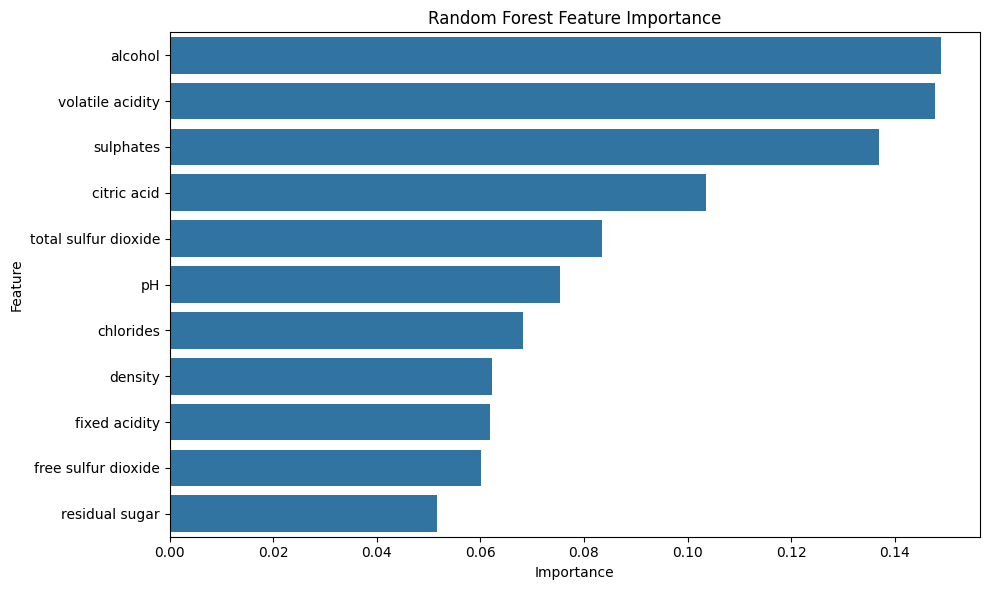

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 15. Model Performance Comparison

The three classification models are compared using accuracy, precision, recall, and F1-score.

Random Forest achieved the strongest overall performance, while SGD Classifier performed better than SVC on accuracy and F1-score.

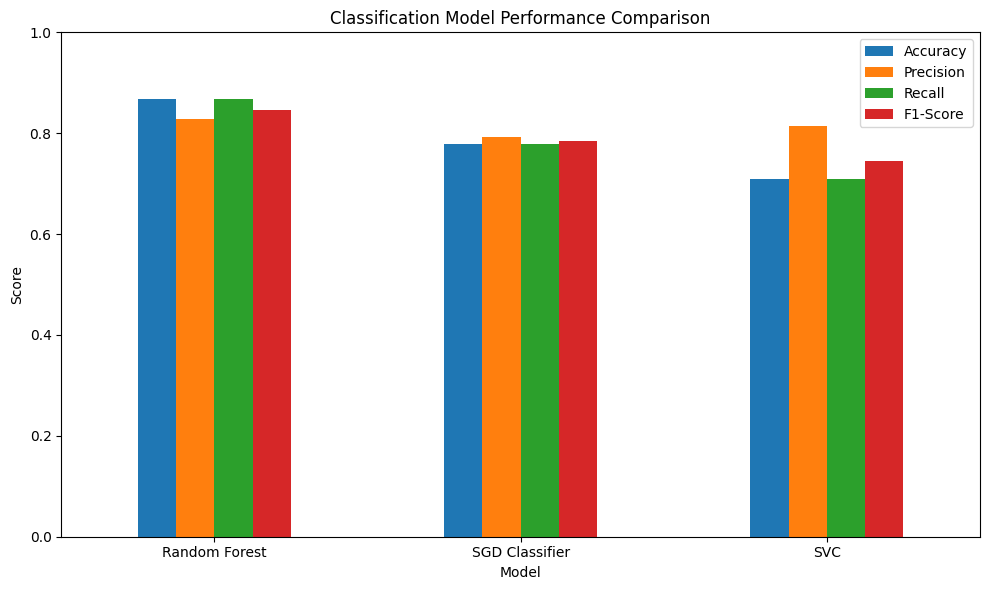

In [46]:
# Model comparison chart

comparison_plot = results_df.set_index("Model")

comparison_plot[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

## 16. Conclusion

This project developed a multi-class classification system for predicting wine quality using physicochemical properties.

The original wine quality scores were converted into three categories:

- Low: quality scores 3–4
- Medium: quality scores 5–6
- High: quality scores 7–8

The dataset was divided into training and testing sets using stratified sampling to preserve the class distribution. Feature scaling was applied for the SGD and SVC models.

Three classification algorithms were evaluated:

1. Random Forest
2. SGD Classifier
3. Support Vector Classifier (SVC)

Random Forest achieved the best overall performance with an accuracy of approximately 86.88% and an F1-score of approximately 84.58%.

SGD Classifier achieved an accuracy of approximately 77.81%, while SVC achieved approximately 70.94%.

The Random Forest feature-importance analysis helps identify which physicochemical properties contribute most to wine-quality classification.

The results demonstrate that machine learning can be used to classify wine quality based on measurable chemical properties. Such models could support quality-control processes, wine production analysis, and automated classification systems.